# Comment évolue l'Afrique par rapport au reste du monde ? (1950 - 2020)

L'espérance de vie regroupe un ensemble de facteurs extrêmement larges autant physiques, que psychologiques mais notamment environnementaux.

L'Afrique est le continent possédant l'espérance de vie la plus basse du monde. En faisant des recherches, j'ai constaté que s'est particulièrement entre 1950 et 1980 qu'un faussé s'est creusé entre l'Afrique du Nord et l'Afrique du Sud. Notre but dans cette analyse sera de determiner les facteurs et leurs évolution en fonction du temps.

Nous allons donc répondre à cette large question avec les deux sous questions suivantes :
- 1) Qu'est ce qui peut expliqué que l'Afrique ait l'espérance de vie plus basse que le reste du monde ?  
- 2) Quel monde sépare l’Afrique du Nord et l’Afrique du Sud ? 


Afin de répondre à la première question, un traitement large de l'ensemble du contient sera effectué. Nous allons comparé l'Afrique au reste du monde. 
Dans le second cas, nous comparons les courbes d'évolution des différents facteurs au sein du continent lui même. Une comparaison avec l'ensemble du monde pourrait être pertinente afin de conclure.

Etant donné la complexcité de cette question, les analyses se restreindront aux axes suivants :
- l'environnement,
- la santé 
- et l'histoire (les guerres)

Les analyses concernant la santé s'appuieront sur des indicateurs tels que le diabète, le cholesterole et l'hypertension mais possiblement aussi sur les consommations personnelles (alcool et tabagisme). Ces analyses pourront englober d'autres facteurs tels que l'hygiène et l'accès à l'eau qui sont fortement corrélés aux conditions de santé des individus.

Les analyses concernant les guerres quant à elles permettront surtout de vérifier si les périodes de guerre coïncident avec la dégradation du niveau de vie globale par exemple.
Et l'environnement, a lui aussi, une forte influence sur l'accessibilité aux soins, à l'eau et autres ressources influant sur la qualité de vie et donc son espérance même, raison pour laquelle il sera traité (de façon complémentaire). 

Les analyses se concentreront principalement sur la santé et seront complétées avec le prisme historique.

C'est avec l'ensemble de ces outils que nous tenterons d'expliquer le cas particulier de l'Afrique et les facteurs responsables de celui-ci.
Evidemment, il est indéniable que nous dresserons une liste non exhaustive. 

Nous tenterons simplement de mettre en lumière les facteurs somatiqus, sociologiques et historiques pricipaux.

Bonne lecture.

In [92]:
# Chargement des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Affichage propre des graphiques
%matplotlib inline

In [93]:
pd.set_option("display.max_columns", None)

In [94]:
health_inequality = pd.read_csv("data/health_inequality.csv") # version nettoyé

C:\Users\juuu4\AppData\Local\Temp\ipykernel_27804\3958986972.py:1: DtypeWarning: Columns (0: assistive_techno) have mixed types. Specify dtype option on import or set low_memory=False.
  health_inequality = pd.read_csv("data/health_inequality.csv") # version nettoyé


In [95]:
health_inequality.tail(5)

,country,country_code,region,income_level,date,update,dataset_id,indicator_abbr,indicator_name,indicator_scale,favourable_indicator,source,dimension,group,subgroup_order,reference_subgroup,ordered_dimension,population,age,cholesterol,assistive_techno,diabetes,hypertension,alcohol,tobacco,value,se,ci_lower,ci_upper,setting_average,flag
895786,occupied Palestinian territory,PSE,Eastern Mediterranean,Lower-middle-income,2021,17 October 2025,rep_gho,WSH_SANITATION_SAFELY_MANAGED,Population using safely managed sanitation ser...,100,1,WHO Global Health Observatory,Place of residence,Urban,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73.45498,NaN,NaN,NaN,68.59957,NaN
895787,occupied Palestinian territory,PSE,Eastern Mediterranean,Lower-middle-income,2021,17 October 2025,rep_gho,WSH_WATER_BASIC,Population using at least basic drinking-water...,100,1,WHO Global Health Observatory,Place of residence,Rural,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.38697,NaN,NaN,NaN,98.17100,NaN
895788,occupied Palestinian territory,PSE,Eastern Mediterranean,Lower-middle-income,2021,17 October 2025,rep_gho,WSH_WATER_BASIC,Population using at least basic drinking-water...,100,1,WHO Global Health Observatory,Place of residence,Urban,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.80785,NaN,NaN,NaN,98.17100,NaN
895789,occupied Palestinian territory,PSE,Eastern Mediterranean,Lower-middle-income,2021,17 October 2025,rep_gho,WSH_WATER_SAFELY_MANAGED,Population using safely managed drinking-water...,100,1,WHO Global Health Observatory,Place of residence,Rural,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76.03888,NaN,NaN,NaN,80.02319,NaN
895790,occupied Palestinian territory,PSE,Eastern Mediterranean,Lower-middle-income,2021,17 October 2025,rep_gho,WSH_WATER_SAFELY_MANAGED,Population using safely managed drinking-water...,100,1,WHO Global Health Observatory,Place of residence,Urban,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,81.21311,NaN,NaN,NaN,80.02319,NaN


### Prétraitement des données - Création de les colonnes 'Africa', 'A_N' et 'A_S' (Afrique du Nord et Afrique du Sud)

Regardons les pays d'afrique disponible dans notre dataset (spoiler normalement, tous) :

In [96]:
print("setting :")
health_inequality.loc[
    health_inequality["region"].str.contains("African", na=False),
    "country"
].unique()

setting :


<StringArray>
[                         'Algeria',                           'Angola',
                            'Benin',                         'Botswana',
                     'Burkina Faso',                          'Burundi',
                       'Cabo Verde',                         'Cameroon',
         'Central African Republic',                             'Chad',
                          'Comoros',                            'Congo',
                    'Côte d'Ivoire', 'Democratic Republic of the Congo',
                'Equatorial Guinea',                          'Eritrea',
                         'Eswatini',                         'Ethiopia',
                            'Gabon',                           'Gambia',
                            'Ghana',                           'Guinea',
                    'Guinea-Bissau',                            'Kenya',
                          'Lesotho',                          'Liberia',
                       'Madagascar', 

Nous allons nous créer une colonne 'Africa' et deux colonne Afrique du Nord (A_N) et Afrique du Sud (A_S)

In [97]:
africa_countries = [
    'Algeria','Angola','Benin','Botswana','Burkina Faso','Burundi',
    'Cabo Verde','Cameroon','Central African Republic','Chad','Comoros',
    'Congo',"Côte d'Ivoire",'Democratic Republic of the Congo','Djibouti',
    'Egypt','Equatorial Guinea','Eritrea','Eswatini','Ethiopia','Gabon',
    'Gambia','Ghana','Guinea','Guinea-Bissau','Kenya','Lesotho','Liberia',
    'Libya','Madagascar','Malawi','Mali','Mauritania','Mauritius',
    'Morocco','Mozambique','Namibia','Niger','Nigeria','Rwanda',
    'Sao Tome and Principe','Senegal','Seychelles','Sierra Leone',
    'Somalia','South Africa','South Sudan','Sudan','Togo','Tunisia',
    'Uganda','United Republic of Tanzania','Zambia','Zimbabwe'
]

In [98]:
north_africa = [
    "Algeria", "Egypt", "Libya", "Morocco", "Sudan", "Tunisia", "Mauritania"
]

In [99]:
health_inequality["Africa"] = health_inequality["country"].isin(africa_countries).astype(int)

health_inequality["A_N"] = health_inequality["country"].isin(north_africa).astype(int)

# Pour avoir des booléen au lieu de 'True' ou 'False'
health_inequality["A_S"] = (
    health_inequality["Africa"].eq(1) &
    ~health_inequality["country"].isin(north_africa)
).astype(int)

On réordonne les colonnes afin de rendre les nouvelles colonnes plus visibles :

In [100]:
health_inequality = health_inequality[[

    # lieux
    "country", "country_code", "region", "Africa", "A_N", "A_S", "income_level",
    "date", "update", "dataset_id",

    # Indicateurs
    "indicator_abbr", "indicator_name", "indicator_scale",
    "favourable_indicator", "source",

    # Regroupements / catégories
    "dimension", "group", "subgroup_order", "reference_subgroup",
    "ordered_dimension", "population", "age",

    # Nouveaux "features"   "alcohol", "tobacco", "diabetes", "hypertension",
    "cholesterol", "assistive_techno", "diabetes", "hypertension", "alcohol", "tobacco",

    # Valeurs
    "value", "se", "ci_lower", "ci_upper",
    "setting_average", "flag"
]]

In [101]:
health_inequality[health_inequality["region"].str.contains("African", na=False)]

,country,country_code,region,Africa,A_N,A_S,income_level,date,update,dataset_id,indicator_abbr,indicator_name,indicator_scale,favourable_indicator,source,dimension,group,subgroup_order,reference_subgroup,ordered_dimension,population,age,cholesterol,assistive_techno,diabetes,hypertension,alcohol,tobacco,value,se,ci_lower,ci_upper,setting_average,flag
9473,Algeria,DZA,African,1,1,0,Upper-middle-income,1954,17 October 2025,rep_gho,MDG_0000000001,Infant mortality rate (deaths per 1000 live bi...,1000,0,WHO Global Health Observatory,Sex,Female,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,159.353961,NaN,118.103407,211.219149,167.099189,NaN
9474,Algeria,DZA,African,1,1,0,Upper-middle-income,1954,17 October 2025,rep_gho,MDG_0000000001,Infant mortality rate (deaths per 1000 live bi...,1000,0,WHO Global Health Observatory,Sex,Male,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,174.172042,NaN,129.706131,230.470696,167.099189,NaN
9475,Algeria,DZA,African,1,1,0,Upper-middle-income,1954,17 October 2025,rep_gho,MDG_0000000007,Under-five mortality rate (model-based estimat...,1000,0,WHO Global Health Observatory,Sex,Female,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,236.485267,NaN,175.394850,312.200659,242.023180,NaN
9476,Algeria,DZA,African,1,1,0,Upper-middle-income,1954,17 October 2025,rep_gho,MDG_0000000007,Under-five mortality rate (model-based estimat...,1000,0,WHO Global Health Observatory,Sex,Male,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,247.100951,NaN,184.045017,325.897248,242.023180,NaN
9477,Algeria,DZA,African,1,1,0,Upper-middle-income,1955,17 October 2025,rep_gho,MDG_0000000001,Infant mortality rate (deaths per 1000 live bi...,1000,0,WHO Global Health Observatory,Sex,Female,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,158.494534,NaN,122.475608,201.760262,166.171077,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
892564,Zimbabwe,ZWE,African,1,0,1,Lower-middle-income,2021,17 October 2025,rep_gho,WSH_SANITATION_SAFELY_MANAGED,Population using safely managed sanitation ser...,100,1,WHO Global Health Observatory,Place of residence,Urban,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.740580,NaN,NaN,NaN,31.802440,NaN
892565,Zimbabwe,ZWE,African,1,0,1,Lower-middle-income,2021,17 October 2025,rep_gho,WSH_WATER_BASIC,Population using at least basic drinking-water...,100,1,WHO Global Health Observatory,Place of residence,Rural,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.695510,NaN,NaN,NaN,62.252800,NaN
892566,Zimbabwe,ZWE,African,1,0,1,Lower-middle-income,2021,17 October 2025,rep_gho,WSH_WATER_BASIC,Population using at least basic drinking-water...,100,1,WHO Global Health Observatory,Place of residence,Urban,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92.760320,NaN,NaN,NaN,62.252800,NaN
892567,Zimbabwe,ZWE,African,1,0,1,Lower-middle-income,2021,17 October 2025,rep_gho,WSH_WATER_SAFELY_MANAGED,Population using safely managed drinking-water...,100,1,WHO Global Health Observatory,Place of residence,Rural,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.630910,NaN,NaN,NaN,26.477000,NaN


### Comment l'espérance de vie a-t-elle évolué dans le monde ?

### Etat des lieux de l'éspérance de vie 2000 - 2020

In [102]:
health_inequality.loc[
    health_inequality["indicator_name"].str.contains("expectancy", na=False),
    "indicator_name"
].unique()

<StringArray>
[                'Life expectancy at birth (years)',
  'Healthy life expectancy (HALE) at birth (years)',
 'Healthy life expectancy (HALE) at age 60 (years)',
                'Life expectancy at age 60 (years)']
Length: 4, dtype: str

In [103]:
df = health_inequality.copy()

df = df[df["indicator_name"] == "Life expectancy at birth (years)"]
df = df[(df["date"] >= 2000) & (df["date"] <= 2020)]

In [104]:
africa = (
    df[df["Africa"] == 1]
    .groupby("date")["value"]
    .mean()
    .reset_index()
    .rename(columns={"value": "Africa"})
)

rest_world = (
    df[df["Africa"] == 0]
    .groupby("date")["value"]
    .mean()
    .reset_index()
    .rename(columns={"value": "Rest of World"})
)

In [105]:
plot_df = pd.merge(africa, rest_world, on="date", how="outer")
plot_df = plot_df.sort_values("date")

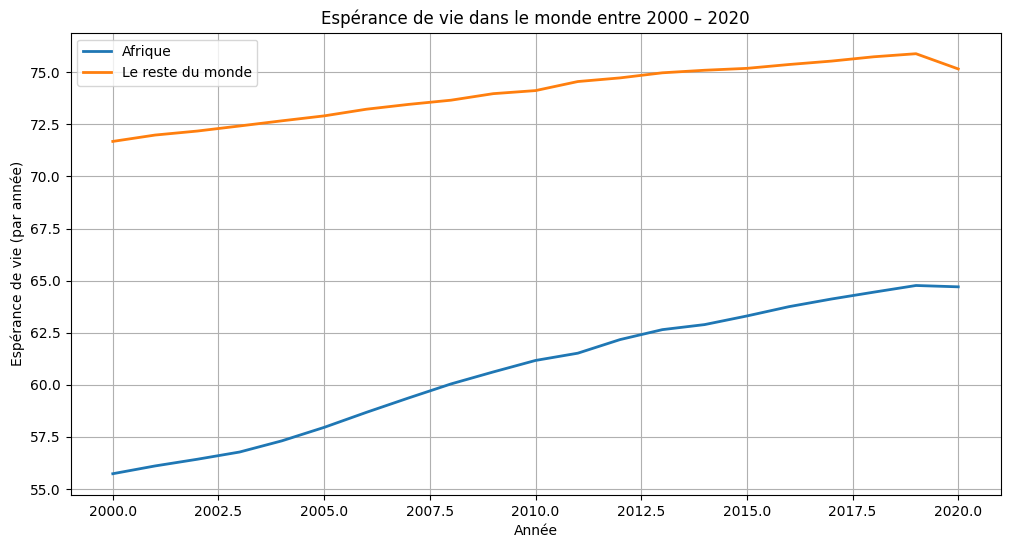

In [106]:
plt.figure(figsize=(12,6))

plt.plot(plot_df["date"], plot_df["Africa"], label="Afrique", linewidth=2)
plt.plot(plot_df["date"], plot_df["Rest of World"], label="Le reste du monde", linewidth=2)

plt.title("Espérance de vie dans le monde entre 2000 – 2020")
plt.xlabel("Année")
plt.ylabel("Espérance de vie (par année)")
plt.legend()
plt.grid(True)

plt.show()

Comme nous pouvons le voir, l'espérance de vie de l'Afrique a toujours été plus basse mais a beaucoup évolué (+ 10 année de gagné en 20 ans).
L'écart avec le reste du monde semble se réduire.

Intéressons nous à la mortalité infantine qui est, indirectement, un très bon indicateur aussi. En effet, cette donnée nous renseigne à la fois sur l'avancé médicale, les soins mais aussi l'hygiène et bien d'autres facteurs.

### Etat des lieux du taux de mortalité infantile 2000 - 2000

In [107]:
health_inequality.loc[
    health_inequality["indicator_name"].str.contains("Infant", na=False),
    "indicator_name"
].unique()

<StringArray>
['Infant mortality rate (deaths per 1000 live births)']
Length: 1, dtype: str

In [108]:
df = health_inequality.copy()

# on s'interesse simplement à l'espérance de vie à la naissance (car c'est celle qui dépend principalement de l'environnement de l'enfant à sa naissance)
df = df[df["indicator_name"] == "Infant mortality rate (deaths per 1000 live births)"] 
df = df[(df["date"] >= 1950) & (df["date"] <= 2020)]

In [109]:
africa = (
    df[df["Africa"] == 1]
    .groupby("date")["value"]
    .mean()
    .reset_index()
    .rename(columns={"value": "Africa"})
)

rest_world = (
    df[df["Africa"] == 0]
    .groupby("date")["value"]
    .mean()
    .reset_index()
    .rename(columns={"value": "Rest of World"})
)

In [110]:
plot_df = pd.merge(africa, rest_world, on="date", how="outer")
plot_df = plot_df.sort_values("date")

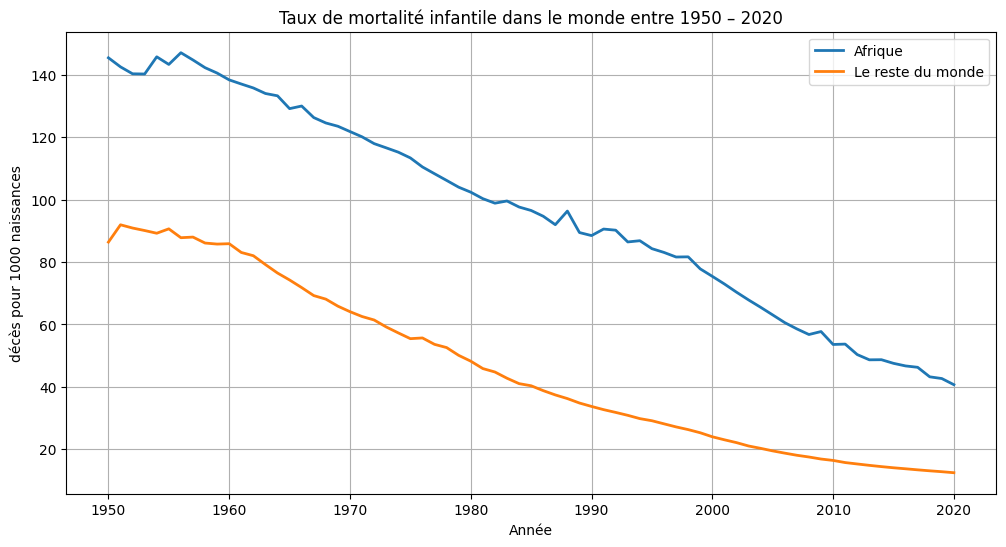

In [113]:
plt.figure(figsize=(12,6))

plt.plot(plot_df["date"], plot_df["Africa"], label="Afrique", linewidth=2)
plt.plot(plot_df["date"], plot_df["Rest of World"], label="Le reste du monde", linewidth=2)

plt.title("Taux de mortalité infantile dans le monde entre 1950 – 2020")
plt.xlabel("Année")
plt.ylabel("décès pour 1000 naissances")
plt.legend()
plt.grid(True)

plt.show()

Le taux de mortalité infantile en Afrique est, lui aussi, drastiquement plus élevé que pour le reste du monde. Ce qui coïncident avec ce que nous avons vu pour l'espérance de vie précédemment. Dès la naissance, un faussé semble présent.

Nous allons donc nous commencer par nous pencher sur l'environnement

## 1) Qu'est ce qui peut expliqué que l'Afrique ait l'espérance de vie plus basse que le reste du monde ?

### I ) L'environnement : avant de s'intéresser à la santé, est-elle accessible ?

En effet, avant de questionner la santé, questionnons son accessibilité. L'accès à la santé ne passe pas uniquement par l'accès aux hopitaux mais l'accès à toutes les ressources dont notre santé dépend : 
- les infrastructures (assistive_techno)
- l'accessibilité à l'eau
- et la propreté, l'hygiène

En effet, si ces élèments sont négligées, cela compromet directement la santé.
Nous allons donc analyser les données liées à ses critères.

Regardons les données disponibles :

In [ ]:
health_inequality.loc[
    health_inequality["indicator_abbr"].str.contains("HYGIENE", na=False),
    "indicator_name"
].unique()

print("\n")

health_inequality.loc[
    health_inequality["indicator_abbr"].str.contains("WATER", na=False),
    "indicator_name"
].unique()

print("\n")

health_inequality.loc[
    health_inequality["indicator_abbr"].str.contains("SANITATION", na=False),
    "indicator_name"
].unique()

<StringArray>
['Population with basic handwashing facilities at home (%)']
Length: 1, dtype: str